# Phase 2

Ce notebook décrit la seconde phase du projet.

1. **Métriques de Qualité (Mathématiques & Statistiques)**
    - Implémente et compare au moins deux métriques pour mesurer la précision de l'alignement.
    - Justifie mathématiquement pourquoi une métrique est plus robuste qu'une autre face à des variations de luminosité ou du bruit capteur.
    
2. **Analyse de Robustesse selon le Paysage**
   - Simule ou utilise des extraits de paysages variés (Urbain, Désert, Montagne).
   - Analyse le comportement de ton algorithme actuel sur ces cas : comment gères-tu l'absence de textures (Désert) ou les distorsions géométriques fortes (Montagne) ?
   - Contrainte NumPy : Propose une méthode de pré-traitement entièrement vectorisée  pour améliorer l'alignement sur les zones à faible contraste.

3. **Algorithmes Alternatifs & Performance**
    - Compare ton approche actuelle avec une approche fréquentielle ou une approche par optimisation locale.
    - Etudie la compléxité algorithmique et l'impact de la résolution des images sur le temps de calcul

## 1. Métriques de Qualité

Je vais implémenter ici 3 métriques pour mesurer la précision de l'alignement.

### Normalized Cross-Correlation (NCC)

La Normalized Cross-Correlation (NCC) est une métrique qui mesure la similarité entre deux images. Elle est définie par ([cf](https://en.wikipedia.org/wiki/Cross-correlation#Normalization))

$$ NCC(I_1, I_2) = \frac{\sum (I_1 - \bar{I_1})(I_2 - \bar{I_2})}{\sqrt{\sum (I_1 - \bar{I_1})^2} \sqrt{\sum (I_2 - \bar{I_2})^2}} $$

In [1]:
import numpy as np


def normalized_cross_correlation(img1, img2):
    img1_mean = np.mean(img1)
    img2_mean = np.mean(img2)

    numerator = np.sum((img1 - img1_mean) * (img2 - img2_mean))
    denominator = np.sqrt(
        np.sum((img1 - img1_mean) ** 2) * np.sum((img2 - img2_mean) ** 2)
    )

    return numerator / denominator

**Robustesse aux variations de luminosité**

Soit $I_1'= a I_1 + b$ (où $a>0$ est un facteur de gain et $b$ un offset), alors

$$ NCC(I_1', I_2) = \frac{\sum (I_1' - \bar{I_1'})(I_2 - \bar{I_2})}{\sqrt{\sum (I_1'- \bar{I_1'})^2} \sqrt{\sum (I_2 - \bar{I_2})^2}}$$
$$= \frac{\sum (a I_1 + b - a\bar{I_1} - b)(I_2 - \bar{I_2})}{\sqrt{\sum (a I_1 + b - a\bar{I_1} - b)^2} \sqrt{\sum (I_2 - \bar{I_2})^2}}$$
$$ = \frac{a \sum (I_1 - \bar{I_1})(I_2 - \bar{I_2})}{\sqrt{a^2 \sum (I_1 - \bar{I_1})^2} \sqrt{\sum (I_2 - \bar{I_2})^2}} $$
$$ = NCC(I_1, I_2) $$

Donc la NCC est invariante aux transformations linéaires de l'intensité, ce qui la rend robuste aux variations **globales** de luminosité. En revanche, elle peut être sensible au bruit local ou aux changements de contraste non linéaires.

**Robustesse au bruit**

Supposons que $I_1' = I_1 + \eta$ où $\eta$ est un bruit additif. Alors
$$ NCC(I_1', I_2) = \frac{\sum (I_1 + \eta - \bar{I_1} - \bar{\eta})(I_2 - \bar{I_2})}{\sqrt{\sum (I_1 + \eta - \bar{I_1} - \bar{n})^2} \sqrt{\sum (I_2 - \bar{I_2})^2}} $$
$$ = \frac{\sum (I_1 - \bar{I_1})(I_2 - \bar{I_2}) + \sum (\eta - \bar{\eta})(I_2 - \bar{I_2})}{\sqrt{\sum (I_1 - \bar{I_1})^2 + \sum (\eta - \bar{\eta})^2 + 2\sum (I_1 - \bar{I_1})(\eta - \bar{n})} \sqrt{\sum (I_2 - \bar{I_2})^2}} $$
Si le bruit est aléatoire et non corrélé avec l'image, alors $\sum (n - \bar{n})(I_2 - \bar{I_2})$ tend à zéro en moyenne et $NCC(I_1', I_2) = NCC(I_1, I_2)$. Cette métrique devient donc robuste au bruit aléatoire. Cependant, le bruit peut augmenter la variance de la métrique et réduire sa fiabilité, surtout si le rapport signal sur bruit est faible.

### Phase correlation (PC)

La correlation de phase se base sur la propriété que les translations dans le domaine spatial correspondent à des décalages de phase dans le domaine fréquentiel. En calculant la transformée de Fourier des deux images et en normalisant le spectre de puissance, on peut identifier la translation maximale qui correspond à l'alignement optimal.

Elle est définie par ([cf](https://en.wikipedia.org/wiki/Phase_correlation))
$$ R = \frac{F_1 \cdot F_2^*}{|F_1 \cdot F_2^*|} $$

Où $F_1$ et $F_2$ sont les transformées de Fourier des deux images (moins la moyenne), et $F_2^*$ est la conjuguée complexe de $F_2$. Le pic dans la fonction de corrélation de phase indique la translation optimale. La métrique implémentée ici consiste en la norme du vecteur de translation estimé, obtenue en prenant la transformée inverse de $R$.

Cette méthode sera la méthode choisie comme approche dites *fréquentielle* pour l'alignement.

In [2]:
def phase_shift(img1, img2, subpixel=False):
    f1 = np.fft.fft2(img1 - np.mean(img1))
    f2 = np.fft.fft2(img2 - np.mean(img2))

    cps = f1 * np.conj(f2)
    # we normalize the cross power spectrum to get only phase information
    # we add a small value to avoid division by zero
    cps /= np.abs(cps) + 1e-12

    corr = np.fft.ifft2(cps)
    corr = np.abs(corr)

    peak = np.unravel_index(np.argmax(corr), corr.shape)
    if subpixel:
        # We will see that later
        # y_sub, x_sub = subpixel_peak(corr, peak)
        pass
    else:
        y_sub, x_sub = peak

    h, w = img1.shape

    # wrap around
    dy = y_sub if y_sub <= h // 2 else y_sub - h
    dx = x_sub if x_sub <= w // 2 else x_sub - w

    return [dy, dx]


def phase_correlation_metric(img1, img2):
    shift = phase_shift(img1, img2)
    return np.linalg.norm(shift)

**Robustesse aux variations de luminosité**

Comme avant, supposons que $I_1' = a I_1 + b$. Alors
$$ F_1' = \mathcal{F}(I_1') = \mathcal{F}(a I_1 + b) = a \mathcal{F}(I_1) + b \mathcal{F}(1) = a F_1 + b \delta(u,v) $$
Où $\delta(u,v)$ est une impulsion de Dirac à (0,0). Lorsque l'on calcule la corrélation de phase, le terme $b \delta(u,v)$ ne contribue qu'à la composante en (0,0) et n'affecte pas les autres fréquences. Par conséquent, la corrélation de phase est également robuste aux transformations linéaires de l'intensité, ce qui la rend adaptée pour l'alignement d'images avec des variations de luminosité globales.

Dans le code, la moyenne est soustraite avant la FFT (`img - np.mean(img)`), l'offset $b$ disparaît donc dès cette étape, indépendamment de la normalisation du spectre de phase.

**Robustesse au bruit**

Supposons que $I_1' = I_1 + \eta$ où $\eta$ est un bruit additif. Alors
$$ F_1' = \mathcal{F}(I_1 + \eta) = F_1 + \mathcal{F}(\eta) = F_1 + N $$
Où $\eta$ est la transformée de Fourier du bruit. La corrélation de phase normalise le spectre de puissance, ce qui peut atténuer l'impact du bruit, surtout si le signal a une énergie significative dans les fréquences pertinentes. Cependant, si le rapport signal sur bruit est très faible, le pic de corrélation peut être noyé dans le bruit, ce qui rend l'estimation de la translation moins précise.

Bien que la précision soit discutable on peut obtenir une estimation sub-pixel en interpolant autour du pic de corrélation (voir plus loin)

### Mutual Information (MI)

Cette métrique calcule la dépendance statistique entre les intensités des deux images. Elle est définie par
([cf](https://en.wikipedia.org/wiki/Mutual_information))

$$ MI(I_1, I_2) = \sum_{i,j} p_{I_1,I_2}(i,j) \log \left( \frac{p_{I_1,I_2}(i,j)}{p_{I_1}(i) p_{I_2}(j)} \right) $$

En d'autres termes, elle mesure la probabilité conjointe des intensités des deux images par rapport à la probabilité marginale de chaque image. La MI est robuste aux variations de luminosité et de contraste, car elle se base sur les distributions d'intensité plutôt que sur les valeurs absolues. Cependant, elle peut être sensible au bruit si les distributions d'intensité sont fortement affectées.

In [3]:
def mutual_information(img1, img2, bins=256, normalize=True):
    img1 = img1.ravel()
    img2 = img2.ravel()

    # Joint histogram
    joint_hist, _, _ = np.histogram2d(img1, img2, bins=bins)

    # Convert to probability
    joint_prob = joint_hist / np.sum(joint_hist)

    # Marginalisartion
    px = np.sum(joint_prob, axis=1)
    py = np.sum(joint_prob, axis=0)

    # Avoid log(0)
    nz = joint_prob > 0

    mi = np.sum(
        joint_prob[nz] * np.log(joint_prob[nz] / (px[:, None] * py[None, :])[nz])
    )

    if normalize:
        nz_x = px > 0
        nz_y = py > 0
        hx = -np.sum(px[nz_x] * np.log(px[nz_x]))
        hy = -np.sum(py[nz_y] * np.log(py[nz_y]))
        denom = hx + hy
        return mi / (denom / 2) if denom > 0 else 0.0

    return mi

**Robustesse aux variations de luminosité**

Supposons que $I_1' = a I_1 + b$. Alors ,

$$ p_{I_1'}(i) = p_{I_1}\left(\frac{i - b}{a}\right) \frac{1}{a} $$
$$ p_{I_1',I_2}(i,j) = p_{I_1,I_2}\left(\frac{i - b}{a}, j\right) \frac{1}{a} $$
En substituant dans la formule de la MI, les facteurs $\frac{1}{a}$ s'annulent dans le rapport logarithmique, ce qui rend la MI invariante aux transformations linéaires de l'intensité. Par conséquent, la MI est également robuste aux variations globales de luminosité.

Cet argument vaut pour les distributions continues. Dans le code, les probabilités sont estimées via un histogramme à `bins=256` cases fixes. Une transformation $I_1' = aI_1 + b$ déplace et étire les bins, donc l'invariance n'est qu'approchée, elle est d'autant meilleure que le nombre de bins est grand.

**Avantage sur NCC et PC**

La MI est en réalité invariante à toute transformation **monotone** de l'intensité (pas seulement linéaire), ce qui la rend plus robuste que la NCC et la PC face à des variations de contraste non linéaires ou à des changements d'exposition locaux. Cependant, elle peut être plus sensible au bruit si les distributions d'intensité sont fortement perturbées, car elle se base sur des estimations de probabilité qui peuvent être affectées par le bruit.

## Application des métriques

Pour tester ces métriques (et pour le reste du notebook), je crée une fonction qui télécharge une image avec des marges plus larges que la bbox de référence, puis fait une translation manuelle de l'image pour simuler un défaut d'alignement

In [4]:
from absens_demo import requests


def translated_image_function(bbox, margin=0.02):
    reference = requests.get_rgb_image(
        "2020-01-01T00:00:00Z", "2024-01-01T00:00:00Z", bbox + margin
    )
    cropped_shape = np.array(reference["rgb"].shape) - int(margin * 10000)
    y0, x0, _ = np.array(reference["rgb"].shape) // 2

    def translated_image(x: int, y: int):
        if abs(x) > margin * 10000 // 2 or abs(y) > margin * 10000 // 2:
            raise ValueError(
                f"Translation exceeds the margin limits {margin * 10000 // 2}"
            )

        image = {}
        for key in ["rgb", "clm"]:
            image[key] = reference[key][
                y0 - cropped_shape[0] // 2 + y : y0 + cropped_shape[0] // 2 + y,
                x0 - cropped_shape[1] // 2 + x : x0 + cropped_shape[1] // 2 + x,
            ]
        return image

    return translated_image

Text(0.5, 1.0, 'Image de référence')

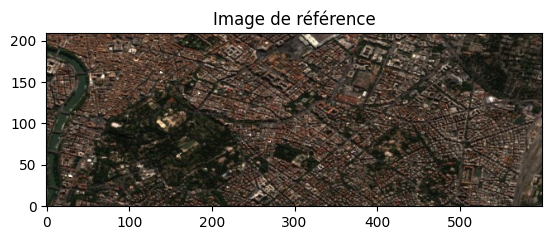

In [5]:
from absens_demo import requests
import matplotlib.pyplot as plt

rome = np.array([12.44, 41.87, 12.52, 41.911])
translated_image = translated_image_function(rome)
plt.imshow(translated_image(0, 0)["rgb"], origin="lower")
plt.title("Image de référence")

Je génère ensuite:
- une série d'images translatées
- une série d'images translatées avec du bruit gaussien

In [6]:
import numpy as np
from skimage.transform import warp, AffineTransform

# translation
x_shifts = np.linspace(0, 30).astype(int)
shifted_images = [translated_image(x, 0) for x in x_shifts]
# gaussian noise
shifted_images_noisy = []
for im in shifted_images:
    noisy_im = im["rgb"] + np.random.normal(0, 0.2, im["rgb"].shape)
    shifted_images_noisy.append({"rgb": noisy_im, "clm": im["clm"]})

**Application des 3 métriques**

Comme décrit dans à la phase 1, l'alignement se fait sur les contours de la moyenne des images RGB. Voici une fonction qui effectue ce pré-traitement et applique la métrique choisie. La métrique est calculée à la fois avant et après l'alignement pour évaluer l'amélioration.

In [7]:
from collections import defaultdict
from absens_demo.alignment import find_translation
from absens_demo.preprocessing import sobel_numpy
from tqdm import tqdm


def analyze_alignment(reference, images):
    ref_edges = sobel_numpy(reference["rgb"].mean(-1))
    metrics = {
        "initial": defaultdict(list),
        "aligned": defaultdict(list),
    }
    methods = [
        phase_correlation_metric,
        normalized_cross_correlation,
        mutual_information,
    ]

    for im in tqdm(images):
        edges = sobel_numpy(im["rgb"].mean(-1))
        try:
            dx, dy = find_translation(ref_edges, edges)
        except Exception as e:
            dx, dy = 0, 0

        aligned_edges = warp(edges, AffineTransform(translation=(dx, dy)))

        for method in methods:
            metric_name = method.__name__
            sim = method(ref_edges, aligned_edges)
            metrics["aligned"][metric_name].append(sim)
            sim = method(ref_edges, edges)
            metrics["initial"][metric_name].append(sim)

    for method in methods:
        for key in ["initial", "aligned"]:
            metrics[key][method.__name__] = np.array(metrics[key][method.__name__])

    return metrics

In [8]:
metrics = analyze_alignment(shifted_images[0], shifted_images)
metrics_noisy = analyze_alignment(shifted_images[0], shifted_images_noisy)

100%|██████████| 50/50 [00:04<00:00, 12.05it/s]


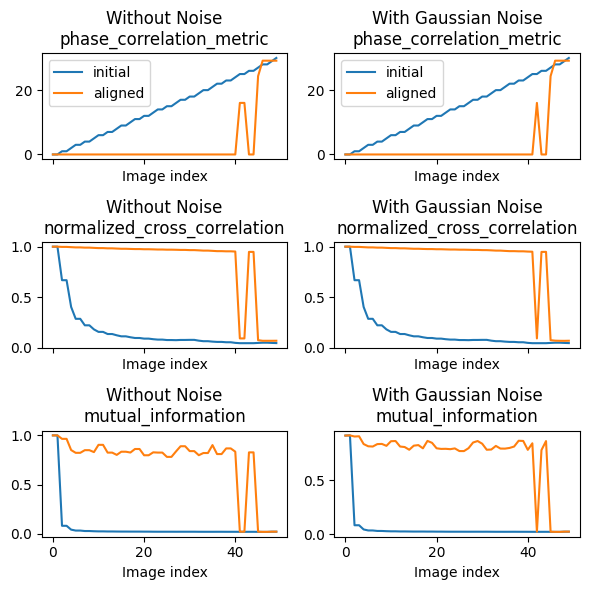

In [9]:
def plot_metrics(metrics, axes=None, title=None):
    if axes is None:
        fig, axes = plt.subplots(
            len(metrics["initial"]),
            1,
            figsize=(5, 2 * len(metrics["initial"])),
            sharex=True,
        )

    for key in ["initial", "aligned"]:
        for i, (metric_name, sims) in enumerate(metrics[key].items()):
            ax = axes[i]
            ax.plot(sims, label=key if i == 0 else None)
            if title is not None:
                ax.set_title(f"{title}\n{metric_name}")
            else:
                ax.set_title(metric_name)
            if i == 0:
                ax.legend()

    for ax in axes:
        ax.set_xlabel("Image index")
    plt.tight_layout()


fig, axes = plt.subplots(
    len(metrics["initial"]),
    2,
    figsize=(6, 2 * len(metrics["initial"])),
    sharex=True,
)


plot_metrics(metrics, axes[:, 0], title="Without Noise")
plot_metrics(metrics_noisy, axes[:, 1], title="With Gaussian Noise")

On remarque plusieurs choses:

- Seule la correlation de phase aboutit à une métrique interprétable: la norme du vecteur de translation estimé entre les deux images, qui est proche de 0 pour un alignement parfait et augmente avec la magnitude de la translation.
- La NCC est aussi interprétable (proche de 1 pour un match exact) mais diminue si l'information présente dans une image n'est pas complètement présente dans l'autre. Ainsi elle cesse d'être interprétable pour de trop grandes translations.

**Note**

Sur des images translatées avec des parties manquantes (masques, nuages), la correlation de phase reste assez fiable mais la NCC perd de son interprétabilité. Afin d'améliorer l'interprétabilité de la NCC j'ai essayé deux solution:
- Un *stretching* de l'histogramme pour matcher l'histogramme de l'image de référence
- Une ranking des pixels par ordre d'intensité avant de calculer la NCC

Aucune de ces deux approches n'a permis d'améliorer significativement l'interprétabilité de la NCC selon moi.

Une dernière métrique plus interpretable serait de calculer la distance euclidienne entre un set de corners/features détectés dans les deux images. Je ne l'ai pas implémenté pour deux raisons:
- Je ne connais qu'une implémentation opencv de cet algorithme et j'ai voulu privilégier des implémentations utilisant numpy dans cette deuxième phase.
- J'ai produit une version numpy de l'algorithme mais en m'aidant trop largement de l'IA. Avec le temps que je me suis fixé je ne pourrais interpréter la robustesse du code ou analyser cette métrique de manière satisfaisante.

## 2. Analyse de Robustesse selon le Paysage - translation simulée

Procédons à une analyse similaire pour différents types de paysages, cette fois ci pour estimer la robustesse de l'algorithme d'alignement lui même. Pour rappel cet algorithme se base sur optimisation locale de l'alignement en utilisant une métrique similaire à la Normalized Cross-Correlation (NCC). L'implémentation est basé sur la fonction opencv `cv2.findTransformECC` comme suit

In [10]:
import cv2
import numpy as np


def find_translation(im0, im1):
    # use findTransformECC from opencv
    # convert to float32
    im0 = im0.astype(np.float32)
    im1 = im1.astype(np.float32)
    # find translation
    warp_matrix = np.eye(2, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 100, 1e-6)
    cc, warp_matrix = cv2.findTransformECC(
        im0, im1, warp_matrix, cv2.MOTION_TRANSLATION, criteria
    )
    return warp_matrix[:2, 2]

### Paysage désertique - faible contraste

Text(0.5, 1.0, 'Image de référence')

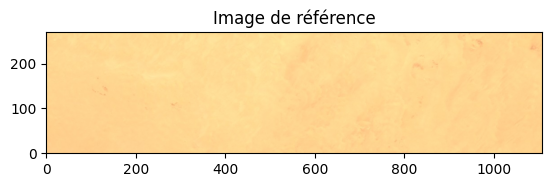

In [11]:
desert = np.array([18.402112, 26.250315, 18.532929, 26.297405])
translated_image = translated_image_function(desert)
plt.imshow(translated_image(0, 0)["rgb"], origin="lower")
plt.title("Image de référence")

Shift des images. Cette fois ci on ajoute un bruit Gaussian directement.

In [12]:
import numpy as np
from skimage.transform import warp, AffineTransform

# translation
x_shifts = np.linspace(0, 30).astype(int)
im_shape = np.array(translated_image(0, 0)["rgb"].shape)
shifted_images = [
    {
        "rgb": translated_image(x, 0)["rgb"] + np.random.normal(0, 0.2, im_shape),
        "clm": translated_image(x, 0)["clm"],
    }
    for x in x_shifts
]

Puis on calcule les métriques avant et après alignement

In [13]:
metrics = analyze_alignment(shifted_images[0], shifted_images)

100%|██████████| 50/50 [00:07<00:00,  6.83it/s]


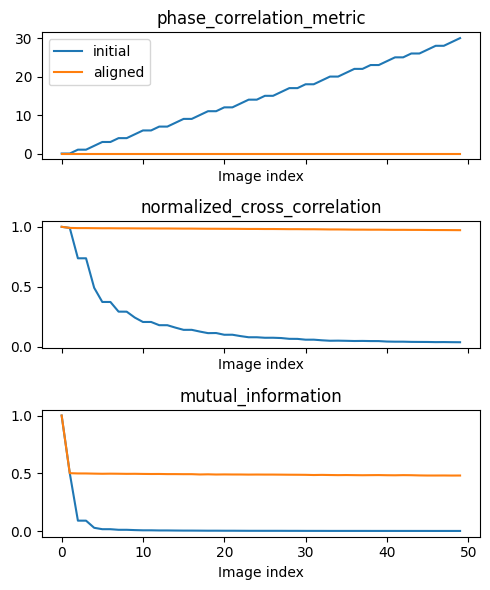

In [14]:
plot_metrics(metrics)

Dans cet example particulier l'algorithme semble fonctionner. Evidemment on parle ici de la même image translatée.

Essayons sur une vraie série d'images.

Text(0.5, 1.0, 'Image de référence')

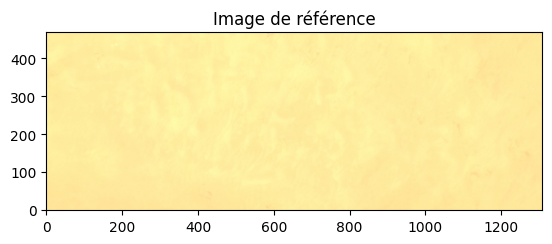

In [15]:
# Download
from pathlib import Path
from absens_demo import requests

data_folder = requests.download_monthly_images(
    desert, "2020-01-01", 30, Path("data/desert")
)
images = list(data_folder.glob("*.npz"))
images = [np.load(im) for im in images]
plt.imshow(images[0]["rgb"], origin="lower")
plt.title("Image de référence")

100%|██████████| 30/30 [00:10<00:00,  2.76it/s]


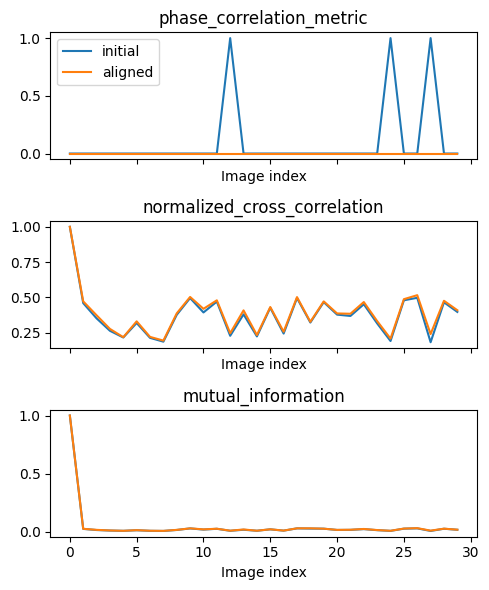

In [16]:
# Metrics
metrics = analyze_alignment(images[0], images)
plot_metrics(metrics)

L'alignement semble bien fonctionner mais encore une fois on se rend compte de la non-interprétabilité de la NCC et de la MI. Comme expliqué plus haut je n'ai pas réussi à corriger cet aspect avec des stratégie de re-normalisation ou de ranking des pixels.

Ici il serait interessant de simulmer une image d'extrêmement faible contraste pour tester les limites de l'algorithme. Sans features notables l'algorithme devrait évidemment échouer à produire un alignement correct, mais il serait intéressant de voir comment les métriques évoluent dans ce cas.

### Paysage urbain

Cette fois ci on télécharge directement une série d'images réelles

Text(0.5, 1.0, 'Image de référence')

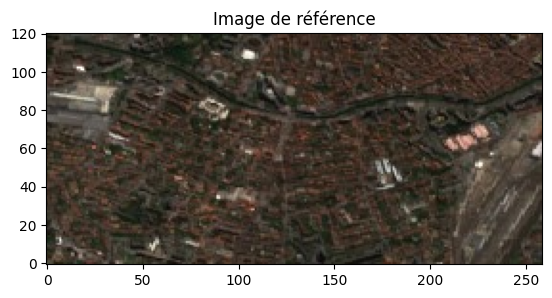

In [17]:
urban = np.array([1.424502, 43.61172, 1.450419, 43.623899])
data_folder = requests.download_monthly_images(
    urban, "2020-01-01", 30, Path("data/urban")
)
images = list(data_folder.glob("*.npz"))
images = [np.load(im) for im in images]
plt.imshow(images[0]["rgb"], origin="lower")
plt.imshow(images[0]["rgb"], origin="lower")
plt.title("Image de référence")

100%|██████████| 30/30 [00:00<00:00, 54.18it/s]


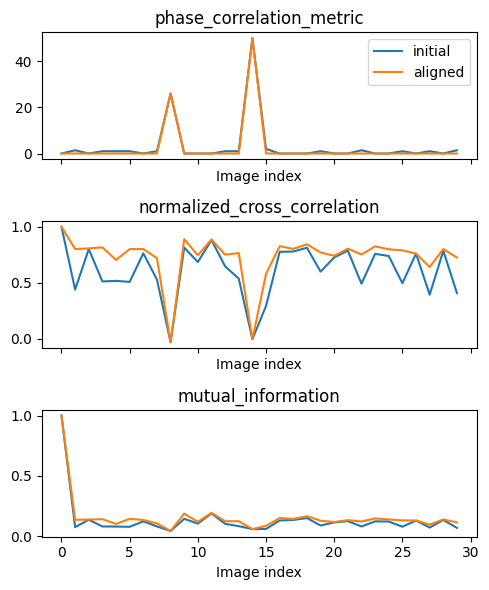

In [18]:
# Metrics
metrics = analyze_alignment(images[0], images)
plot_metrics(metrics)

Si l'on s'attarde sur les images qui n'ont pas fonctionné, on remarque que ce sont des images avec des nuages ou des masques importants.

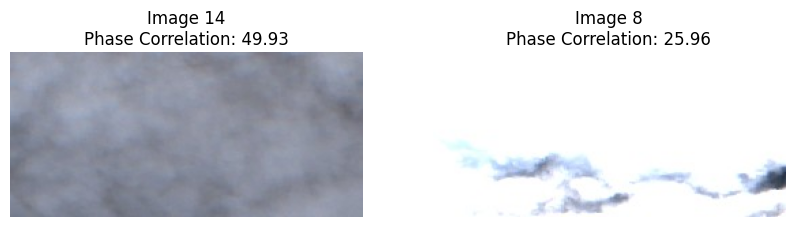

In [19]:
def plot_worst_aligned_images(metrics, images, threshold=5):

    worst_aligned_idx = np.argsort(metrics["aligned"]["phase_correlation_metric"])[::-1]
    worst_aligned_idx = worst_aligned_idx[
        metrics["aligned"]["phase_correlation_metric"][worst_aligned_idx] >= threshold
    ]

    fig, axes = plt.subplots(
        1, len(worst_aligned_idx), figsize=(5 * len(worst_aligned_idx), 5)
    )
    if len(worst_aligned_idx) == 1:
        axes = [axes]
    for i, idx in enumerate(worst_aligned_idx):
        axes[i].imshow(images[idx]["rgb"], origin="lower")
        axes[i].set_title(
            f"Image {idx}\nPhase Correlation: {metrics['aligned']['phase_correlation_metric'][idx]:.2f}"
        )
        axes[i].axis("off")


plot_worst_aligned_images(metrics, images)

### Paysage montagneux

Enfin, pour un paysage montagneux

Text(0.5, 1.0, 'Image de référence')

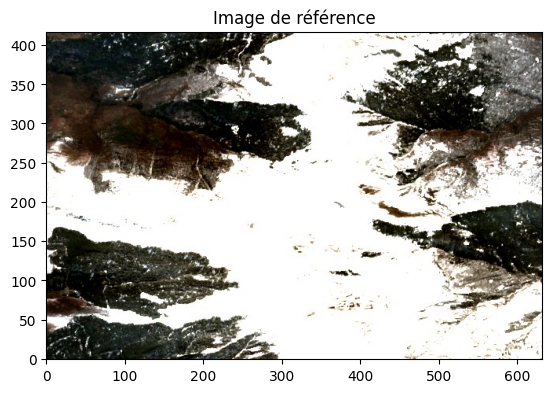

In [20]:
mountains = np.array([0.630281, 42.804469, 0.693506, 42.84626])
data_folder = requests.download_monthly_images(
    mountains, "2020-01-01", 30, Path("data/moutains")
)
images = list(data_folder.glob("*.npz"))
images = [np.load(im) for im in images]
plt.imshow(images[0]["rgb"], origin="lower")
plt.imshow(images[0]["rgb"], origin="lower")
plt.title("Image de référence")

100%|██████████| 30/30 [00:03<00:00,  8.65it/s]


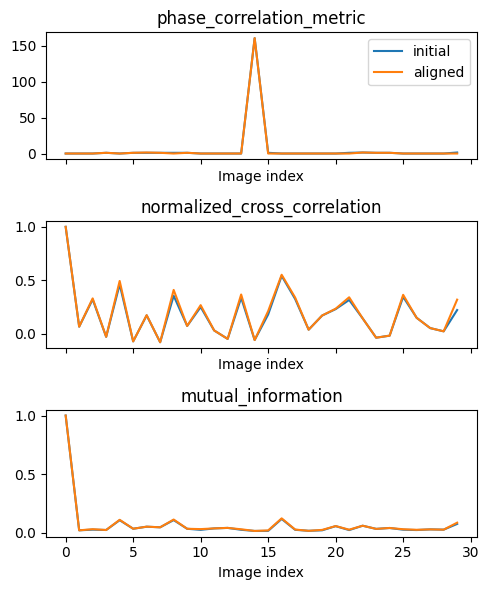

In [21]:
# Metrics
metrics = analyze_alignment(images[0], images)
plot_metrics(metrics)

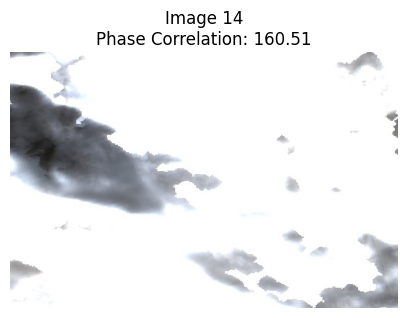

In [22]:
plot_worst_aligned_images(metrics, images)

Même conclusion que précédemment, les images avec des nuages ou des masques importants peuvent être impossibles à aligner.

#### Distorsions géométriques 

Bien qu'on ne semble pas être en présence de fortes distorsions géométriques dans ce cas particulier, l'algorithme implémenté ne serait pas capable de prendre en compte ce genre de déformations. Dans ces cas un algorithme de type *feature-based* serait plus adapté.

### Pré-traitement numpy

Dans l'algorithme implémenté en phase 1 du projet, la phase de pré-traitement consiste à calculer la moyenne des canaux RGB et à appliquer un filtre de Sobel pour extraire les contours.

Le code qui suit (déjà utilisé au-dessus) propose une implémentation numpy vectorisé du filtre de Sobel pour extraire les contours d'une image.

In [23]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view


def sobel_fast(image: np.ndarray) -> np.ndarray:
    """Filtre de Sobel full numpy.

    Parameters
    ----------
    image : np.ndarray
        Greyscale image

    Returns
    -------
    np.ndarray
        Image de contours
    """
    # https://fr.wikipedia.org/wiki/Filtre_de_Sobel
    image = image.astype(np.float64)

    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

    padded = np.pad(image, 1, mode="reflect")

    windows = sliding_window_view(padded, (3, 3))  # (H, W, 3, 3)

    gx = np.tensordot(windows, Kx, axes=((2, 3), (0, 1)))
    gy = np.tensordot(windows, Ky, axes=((2, 3), (0, 1)))

    magnitude = np.sqrt(gx**2 + gy**2)

    return magnitude

D'autres solutions de pré-traitement pourraient être envisagées, comme:
- Le stretching de l'histogramme pour améliorer la distribution d'intensité entre l'image de référence et l'image à aligner (développé dans [`preprocessing.match_histogram`](./src/absens_demo/preprocessing.py) par example)
- L'application d'un filtre Gaussien pour réduire le bruit avant l'extraction des contours

## 3. Algorithmes Alternatifs & Performance

L'approche utilisée dans la phase 1 du projet est une optimisation locale utilisant une métrique similaire à la Normalized Cross-Correlation (NCC) définie plus haut. Elle a le désavantage d'avoir un temps d'exécution non prédictible et de dépendre fortement de conditions initiales. On peut remédier au premier point en limitant le nombre d'itérations. Pour ce faire une implémentation numpy serait désirable et permettrait une plus grande flexbilité d'optimisations et moins de dépendance à une librairie massive tel que opencv.

Si M est le nombre maximal d'itération, la complexité de cette approche est de l'ordre de O(M * N) où N est le nombre de pixels dans l'image.

### Brève étude des performances de la correlation de phase

In [26]:
import time

processing_time = {}
images = [
    np.random.rand(n, n).astype(np.uint8) for n in [100, 200, 300, 500, 800, 1000, 2000]
]
for im in tqdm(images):
    N = im.shape[0] * im.shape[1]
    tic = time.time()
    for _ in range(10):
        phase_shift(im, im)
    toc = time.time()
    processing_time[N] = (toc - tic) / 10

100%|██████████| 7/7 [00:02<00:00,  2.54it/s]


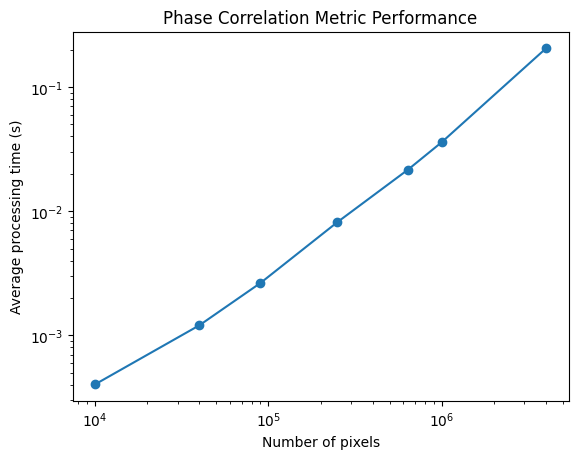

In [27]:
plt.plot(list(processing_time.keys()), list(processing_time.values()), marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of pixels")
plt.ylabel("Average processing time (s)")
_ = plt.title("Phase Correlation Metric Performance")

L'approche fréquentielle, utilisant la fonction `phase_shift` définie plus haut est quant à elle d'une complexité de l'ordre de O(N log N) en raison de la FFT.

## Pour aller plus loin

Afin d'étudier ces métriques en détails il faudrait générer des images réelles shifté (i.e. de vraies images avec une bbox shifté pour simuler un défaut d'alignement) et calculer les métriques sur ces images dans un espace contraint de paramètres (bruit, magnitude de la translation, présence de nuages/masques, etc). Cela permettrait d'avoir une meilleure compréhension de la robustesse de ces métriques et de leur interprétabilité dans différents scénarios. Il se pourrait qu'une étape de classification de paysage soit un atout majeur dans un pipeline en production, et permettrait au cas par cas d'utiliser la méthode de traitement appropriée.

Un élément manquant dans mon étude est l'implémentation d'une approche de type *feature-based* pour l'alignement, qui serait plus robuste aux distorsions géométriques.

En termes de performance, la plupart des algorithmes développé ici sont très simples et ne sont pas particulièrement optimisé. Le fait qu'ils puissent être exécuté en quelques secondes sur des images de résolution modérée est suffisant pour une preuve de concept, mais pour une utilisation en production il faudrait envisager des optimisations plus poussées, notamment en utilisant des implémentations bas niveau ou en exploitant le parallélisme.